# 第11章 動学ゲーム: 反実仮想シミュレーション

2企業の参入退出の動的ゲームにおいて、パラメータを変化させた
反実仮想シミュレーション（Counterfactual Policy Simulation）を行う。

- シナリオ1: 企業1のベース利潤が上昇し、顧客奪取効果が両企業とも0になった場合
- シナリオ2: 企業1のベース利潤が上昇し、顧客奪取効果に企業間で異質性がある場合

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定
import matplotlib
font_candidates = [
    'Hiragino Sans',
    'Hiragino Kaku Gothic ProN',
    'IPAexGothic',
    'Noto Sans CJK JP',
    'Yu Gothic',
    'MS Gothic',
]
available_fonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
jp_font = None
for fc in font_candidates:
    if fc in available_fonts:
        jp_font = fc
        break
if jp_font:
    plt.rcParams['font.family'] = jp_font
    print(f"日本語フォント: {jp_font}")
else:
    print("警告: 日本語フォントが見つかりません。文字化けの可能性があります。")
plt.rcParams['axes.unicode_minus'] = False

# パス設定
base_dir = Path('..')
output_dir = base_dir / 'output'
output_dir.mkdir(exist_ok=True)

print("Setup complete.")


日本語フォント: Hiragino Sans
Setup complete.


## パラメータの設定

In [2]:
# 割引因子
beta = 0.8

# オイラー定数
eulergamma = 0.5772

# 景気の遷移行列: [[P(G|G), P(B|G)], [P(G|B), P(B|B)]]
TransitionMat = np.array([[0.7, 0.3],
                          [0.4, 0.6]])

# パラメータの設定
# Parameters[0]: 企業1のベース利潤
# Parameters[1]: 企業2のベース利潤
# Parameters[2]: 顧客収奪効果
# Parameters[3]: 景気が良い時の追加的利潤
# Parameters[4]: 退出のためのコスト
# Parameters[5]: 参入のためのコスト
Parameters = np.array([0.3, 0.2, -0.27, 0.45, -0.15, -2.10])

# ベースラインパラメータ (10x1)
# theta[0]: 企業1のベース利潤
# theta[1]: ライバルの店舗数が企業1の利潤に与える影響
# theta[2]: 景気が良い時の企業1への追加的利潤
# theta[3]: 企業1の退出のためのコスト
# theta[4]: 企業1の出店のためのコスト
# theta[5]-theta[9]: 企業2について同様
BaselineParameterValues = np.array([
    Parameters[0],   # 企業1のベース利潤
    Parameters[2],   # ライバルの店舗数が企業1の利潤に与える影響
    Parameters[3],   # 景気が良い時の企業1への追加的利潤
    Parameters[4],   # 企業1の退出のためのコスト
    Parameters[5],   # 企業1の出店のためのコスト
    Parameters[1],   # 企業2のベース利潤
    Parameters[2],   # ライバルの店舗数が企業2の利潤に与える影響
    Parameters[3],   # 景気が良い時の企業2への追加的利潤
    Parameters[4],   # 企業2の退出のためのコスト
    Parameters[5],   # 企業2の出店のためのコスト
])

print("パラメータ設定完了")
print(f"beta = {beta}")
print(f"遷移行列:\n{TransitionMat}")
print(f"BaselineParameterValues = {BaselineParameterValues}")


パラメータ設定完了
beta = 0.8
遷移行列:
[[0.7 0.3]
 [0.4 0.6]]
BaselineParameterValues = [ 0.3  -0.27  0.45 -0.15 -2.1   0.2  -0.27  0.45 -0.15 -2.1 ]


## CCP Adjuster の定義

In [3]:
# CCP Adjuster: 各状態で選択可能な行動に1、不可能な行動に0を割り当てる行列 (8x3)
# 列は a_i = -1, 0, 1 に対応
# 状態: G00, G01, G10, G11, B00, B01, B10, B11

# 企業1について:
#   n1=0 のとき: a1=-1 は不可, a1=0 は可, a1=1 は可 → [0,1,1]
#   n1=1 のとき: a1=-1 は可, a1=0 は可, a1=1 は不可 → [1,1,0]
CCP1Adjuster = np.array([
    [0, 1, 1],  # G00: n1=0
    [0, 1, 1],  # G01: n1=0
    [1, 1, 0],  # G10: n1=1
    [1, 1, 0],  # G11: n1=1
    [0, 1, 1],  # B00: n1=0
    [0, 1, 1],  # B01: n1=0
    [1, 1, 0],  # B10: n1=1
    [1, 1, 0],  # B11: n1=1
], dtype=float)

# 企業2について:
#   n2=0 のとき: [0,1,1]
#   n2=1 のとき: [1,1,0]
CCP2Adjuster = np.array([
    [0, 1, 1],  # G00: n2=0
    [1, 1, 0],  # G01: n2=1
    [0, 1, 1],  # G10: n2=0
    [1, 1, 0],  # G11: n2=1
    [0, 1, 1],  # B00: n2=0
    [1, 1, 0],  # B01: n2=1
    [0, 1, 1],  # B10: n2=0
    [1, 1, 0],  # B11: n2=1
], dtype=float)

print("CCP1Adjuster (8x3):")
print(CCP1Adjuster)
print("\nCCP2Adjuster (8x3):")
print(CCP2Adjuster)


CCP1Adjuster (8x3):
[[0. 1. 1.]
 [0. 1. 1.]
 [1. 1. 0.]
 [1. 1. 0.]
 [0. 1. 1.]
 [0. 1. 1.]
 [1. 1. 0.]
 [1. 1. 0.]]

CCP2Adjuster (8x3):
[[0. 1. 1.]
 [1. 1. 0.]
 [0. 1. 1.]
 [1. 1. 0.]
 [0. 1. 1.]
 [1. 1. 0.]
 [0. 1. 1.]
 [1. 1. 0.]]


## 利潤関数・CCP変換関数の定義

In [4]:
def pi1gen(theta):
    """企業1の利潤行列を生成する (8x3)
    行: 状態 (G00, G01, G10, G11, B00, B01, B10, B11)
    列: 行動 (a1=-1, a1=0, a1=1)
    """
    base = np.array([
        0,                              # G00: n1=0
        0,                              # G01: n1=0
        theta[0] + theta[2],            # G10: n1=1, 好景気
        theta[0] + theta[1] + theta[2], # G11: n1=1, 好景気, ライバルあり
        0,                              # B00: n1=0
        0,                              # B01: n1=0
        theta[0],                       # B10: n1=1
        theta[0] + theta[1],            # B11: n1=1, ライバルあり
    ])
    invdiv = np.array([theta[3], 0, theta[4]])
    output = np.tile(base.reshape(-1, 1), (1, 3)) + np.tile(invdiv.reshape(1, -1), (8, 1))
    return output


def pi2gen(theta):
    """企業2の利潤行列を生成する (8x3)"""
    base = np.array([
        0,                              # G00: n2=0
        theta[5] + theta[7],            # G01: n2=1, 好景気
        0,                              # G10: n2=0
        theta[5] + theta[6] + theta[7], # G11: n2=1, 好景気, ライバルあり
        0,                              # B00: n2=0
        theta[5],                       # B01: n2=1
        0,                              # B10: n2=0
        theta[5] + theta[6],            # B11: n2=1, ライバルあり
    ])
    invdiv = np.array([theta[8], 0, theta[9]])
    output = np.tile(base.reshape(-1, 1), (1, 3)) + np.tile(invdiv.reshape(1, -1), (8, 1))
    return output


def CCP1Transform(x):
    """CCP1ベクトル (8,) を CCP1行列 (8x3) に変換する
    x[s]: 状態sにおける現状維持(a1=0)の確率
    """
    return np.array([
        [0,        x[0], 1-x[0]],  # G00: n1=0
        [0,        x[1], 1-x[1]],  # G01: n1=0
        [1-x[2],   x[2], 0      ],  # G10: n1=1
        [1-x[3],   x[3], 0      ],  # G11: n1=1
        [0,        x[4], 1-x[4]],  # B00: n1=0
        [0,        x[5], 1-x[5]],  # B01: n1=0
        [1-x[6],   x[6], 0      ],  # B10: n1=1
        [1-x[7],   x[7], 0      ],  # B11: n1=1
    ])


def CCP2Transform(x):
    """CCP2ベクトル (8,) を CCP2行列 (8x3) に変換する"""
    return np.array([
        [0,        x[0], 1-x[0]],  # G00: n2=0
        [1-x[1],   x[1], 0      ],  # G01: n2=1
        [0,        x[2], 1-x[2]],  # G10: n2=0
        [1-x[3],   x[3], 0      ],  # G11: n2=1
        [0,        x[4], 1-x[4]],  # B00: n2=0
        [1-x[5],   x[5], 0      ],  # B01: n2=1
        [0,        x[6], 1-x[6]],  # B10: n2=0
        [1-x[7],   x[7], 0      ],  # B11: n2=1
    ])


def CCP1LogTransform(x):
    """CCP1ベクトル (8,) を log CCP1行列 (8x3) に変換する"""
    return np.array([
        [0,              np.log(x[0]), np.log(1-x[0])],
        [0,              np.log(x[1]), np.log(1-x[1])],
        [np.log(1-x[2]), np.log(x[2]), 0             ],
        [np.log(1-x[3]), np.log(x[3]), 0             ],
        [0,              np.log(x[4]), np.log(1-x[4])],
        [0,              np.log(x[5]), np.log(1-x[5])],
        [np.log(1-x[6]), np.log(x[6]), 0             ],
        [np.log(1-x[7]), np.log(x[7]), 0             ],
    ])


def CCP2LogTransform(x):
    """CCP2ベクトル (8,) を log CCP2行列 (8x3) に変換する"""
    return np.array([
        [0,              np.log(x[0]), np.log(1-x[0])],
        [np.log(1-x[1]), np.log(x[1]), 0             ],
        [0,              np.log(x[2]), np.log(1-x[2])],
        [np.log(1-x[3]), np.log(x[3]), 0             ],
        [0,              np.log(x[4]), np.log(1-x[4])],
        [np.log(1-x[5]), np.log(x[5]), 0             ],
        [0,              np.log(x[6]), np.log(1-x[6])],
        [np.log(1-x[7]), np.log(x[7]), 0             ],
    ])


print("利潤関数・CCP変換関数定義完了")


利潤関数・CCP変換関数定義完了


## 遷移行列の構築関数

In [5]:
def fP(Matrix1, Vec1, Vec2):
    """CCPの下での状態遷移行列 F^{P,sigma} を構築する (8x8)

    Parameters
    ----------
    Matrix1 : (2,2) 景気の遷移行列
    Vec1 : (8,) 企業1のCCPベクトル (P(stay))
    Vec2 : (8,) 企業2のCCPベクトル (P(stay))
    """
    TempMat0 = np.kron(Matrix1, np.ones((4, 4)))

    rows1 = np.array([
        [Vec1[0], 1-Vec1[0]],
        [Vec1[1], 1-Vec1[1]],
        [1-Vec1[2], Vec1[2]],
        [1-Vec1[3], Vec1[3]],
        [Vec1[4], 1-Vec1[4]],
        [Vec1[5], 1-Vec1[5]],
        [1-Vec1[6], Vec1[6]],
        [1-Vec1[7], Vec1[7]],
    ])
    TempMat1 = np.kron(rows1, np.ones((1, 2)))
    TempMat1 = np.hstack([TempMat1, TempMat1])

    rows2 = np.array([
        [Vec2[0], 1-Vec2[0]],
        [1-Vec2[1], Vec2[1]],
        [Vec2[2], 1-Vec2[2]],
        [1-Vec2[3], Vec2[3]],
        [Vec2[4], 1-Vec2[4]],
        [1-Vec2[5], Vec2[5]],
        [Vec2[6], 1-Vec2[6]],
        [1-Vec2[7], Vec2[7]],
    ])
    TempMat2 = np.kron(np.ones((1, 4)), rows2)

    output = TempMat0 * TempMat1 * TempMat2
    return output


def fP_a1given(Matrix1, Vec2):
    """企業1の行動を条件付けた状態遷移行列のリスト [a1=-1, a1=0, a1=1] (各8x8)"""
    TempMat0 = np.kron(Matrix1, np.ones((4, 4)))

    rows2 = np.array([
        [Vec2[0], 1-Vec2[0], Vec2[0], 1-Vec2[0]],
        [1-Vec2[1], Vec2[1], 1-Vec2[1], Vec2[1]],
        [Vec2[2], 1-Vec2[2], Vec2[2], 1-Vec2[2]],
        [1-Vec2[3], Vec2[3], 1-Vec2[3], Vec2[3]],
        [Vec2[4], 1-Vec2[4], Vec2[4], 1-Vec2[4]],
        [1-Vec2[5], Vec2[5], 1-Vec2[5], Vec2[5]],
        [Vec2[6], 1-Vec2[6], Vec2[6], 1-Vec2[6]],
        [1-Vec2[7], Vec2[7], 1-Vec2[7], Vec2[7]],
    ])
    TempMat2 = np.hstack([rows2, rows2])

    # a1 = -1: 退出 → n1'=0
    vec_m1 = np.concatenate([np.zeros(16), np.ones(16), np.zeros(16), np.ones(16)])
    MatAdjustMinus1 = vec_m1.reshape(8, 8, order='C')
    vec_m2 = np.concatenate([np.ones(16), np.zeros(16), np.ones(16), np.zeros(16)])
    MatAdjustMinus2 = vec_m2.reshape(8, 8, order='F')
    output1 = TempMat0 * TempMat2 * MatAdjustMinus1 * MatAdjustMinus2

    # a1 = 0: 現状維持
    ForZero = np.array([[1, 0], [0, 1]])
    block = np.kron(ForZero, np.ones((2, 2)))
    MatAdjustZero = np.hstack([block, block])
    MatAdjustZero = np.vstack([MatAdjustZero, MatAdjustZero])
    output2 = TempMat0 * TempMat2 * MatAdjustZero

    # a1 = 1: 参入 → n1'=1
    vec_p1 = np.concatenate([np.ones(16), np.zeros(16), np.ones(16), np.zeros(16)])
    MatAdjustPlus1 = vec_p1.reshape(8, 8, order='C')
    vec_p2 = np.concatenate([np.zeros(16), np.ones(16), np.zeros(16), np.ones(16)])
    MatAdjustPlus2 = vec_p2.reshape(8, 8, order='F')
    output3 = TempMat0 * TempMat2 * MatAdjustPlus1 * MatAdjustPlus2

    return [output1, output2, output3]


def fP_a2given(Matrix1, Vec1):
    """企業2の行動を条件付けた状態遷移行列のリスト [a2=-1, a2=0, a2=1] (各8x8)"""
    TempMat0 = np.kron(Matrix1, np.ones((4, 4)))

    rows1 = np.array([
        [Vec1[0], Vec1[0], 1-Vec1[0], 1-Vec1[0]],
        [Vec1[1], Vec1[1], 1-Vec1[1], 1-Vec1[1]],
        [1-Vec1[2], 1-Vec1[2], Vec1[2], Vec1[2]],
        [1-Vec1[3], 1-Vec1[3], Vec1[3], Vec1[3]],
        [Vec1[4], Vec1[4], 1-Vec1[4], 1-Vec1[4]],
        [Vec1[5], Vec1[5], 1-Vec1[5], 1-Vec1[5]],
        [1-Vec1[6], 1-Vec1[6], Vec1[6], Vec1[6]],
        [1-Vec1[7], 1-Vec1[7], Vec1[7], Vec1[7]],
    ])
    TempMat1 = np.kron(np.ones((1, 2)), rows1)

    # a2 = -1
    vec_m1 = np.tile(np.concatenate([np.zeros(8), np.ones(8)]), 4)
    MatAdjustMinus1 = vec_m1.reshape(8, 8, order='C')
    vec_m2 = np.tile(np.concatenate([np.ones(8), np.zeros(8)]), 4)
    MatAdjustMinus2 = vec_m2.reshape(8, 8, order='F')
    output1 = TempMat0 * TempMat1 * MatAdjustMinus1 * MatAdjustMinus2

    # a2 = 0
    ForZero = np.array([1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1], dtype=float)
    vec_z = np.tile(ForZero, 4)
    MatAdjustZero = vec_z.reshape(8, 8, order='C')
    output2 = TempMat0 * TempMat1 * MatAdjustZero

    # a2 = 1
    vec_p1 = np.tile(np.concatenate([np.ones(8), np.zeros(8)]), 4)
    MatAdjustPlus1 = vec_p1.reshape(8, 8, order='C')
    vec_p2 = np.tile(np.concatenate([np.zeros(8), np.ones(8)]), 4)
    MatAdjustPlus2 = vec_p2.reshape(8, 8, order='F')
    output3 = TempMat0 * TempMat1 * MatAdjustPlus1 * MatAdjustPlus2

    return [output1, output2, output3]


def pi1PsigmaGen(pi1, Mat2):
    """企業2のCCP行列 Mat2 の下での企業1の期待利潤 (8x3)"""
    ones3 = np.ones(3)
    pi1_dec = (pi1[:, 0].reshape(-1, 1) * Mat2) @ ones3
    pi1_0   = (pi1[:, 1].reshape(-1, 1) * Mat2) @ ones3
    pi1_inc = (pi1[:, 2].reshape(-1, 1) * Mat2) @ ones3
    return np.column_stack([pi1_dec, pi1_0, pi1_inc])


def pi2PsigmaGen(pi2, Mat1):
    """企業1のCCP行列 Mat1 の下での企業2の期待利潤 (8x3)"""
    ones3 = np.ones(3)
    pi2_dec = (pi2[:, 0].reshape(-1, 1) * Mat1) @ ones3
    pi2_0   = (pi2[:, 1].reshape(-1, 1) * Mat1) @ ones3
    pi2_inc = (pi2[:, 2].reshape(-1, 1) * Mat1) @ ones3
    return np.column_stack([pi2_dec, pi2_0, pi2_inc])


print("遷移行列・期待利潤関数定義完了")


遷移行列・期待利潤関数定義完了


## MPEソルバーの定義

In [6]:
def f_MPE(TransitionMat, pi1, pi2, beta, tol=1e-12):
    """マルコフ完全均衡（MPE）を固定点反復で計算する

    Parameters
    ----------
    TransitionMat : (2,2) 景気の遷移行列
    pi1 : (8,3) 企業1の利潤行列 (CCP Adjuster 適用済み)
    pi2 : (8,3) 企業2の利潤行列 (CCP Adjuster 適用済み)
    beta : float 割引因子
    tol : float 収束判定の閾値

    Returns
    -------
    CCP1UpdatedMat : (8,3) 企業1の均衡CCP行列
    CCP2UpdatedMat : (8,3) 企業2の均衡CCP行列
    ExanteV1 : (8,) 企業1の事前価値関数
    ExanteV2 : (8,) 企業2の事前価値関数
    """
    # Step 1: CCPの初期値
    CCP1 = np.full(8, 0.5)
    CCP2 = np.full(8, 0.5)

    CCP1Mat = CCP1Transform(CCP1)
    CCP2Mat = CCP2Transform(CCP2)

    # Step 2: 事前の価値関数を計算
    fPsigma = fP(TransitionMat, CCP1, CCP2)
    pi1Psigma = pi1PsigmaGen(pi1, CCP2Mat)
    pi2Psigma = pi2PsigmaGen(pi2, CCP1Mat)
    eP1 = eulergamma - CCP1LogTransform(CCP1)
    eP2 = eulergamma - CCP2LogTransform(CCP2)

    inv_mat = np.linalg.inv(np.eye(8) - beta * fPsigma)
    ExanteV1 = inv_mat @ np.sum(CCP1Mat * (pi1Psigma + eP1), axis=1)
    ExanteV2 = inv_mat @ np.sum(CCP2Mat * (pi2Psigma + eP2), axis=1)

    # Step 3: CCPの更新
    fP_a1 = fP_a1given(TransitionMat, CCP2)
    fP_a2 = fP_a2given(TransitionMat, CCP1)

    future1 = np.column_stack([fP_a1[k] @ ExanteV1 for k in range(3)])
    NewSigmaSeed1 = (pi1Psigma + beta * future1) * CCP1Adjuster
    NewSigmaDeno1 = np.sum(np.exp(NewSigmaSeed1), axis=1) - 1.0
    NewSigma1 = np.exp(NewSigmaSeed1) / NewSigmaDeno1.reshape(-1, 1)
    CCP1UpdatedMat = NewSigma1 * CCP1Adjuster
    CCP1Updated = CCP1UpdatedMat[:, 1]

    future2 = np.column_stack([fP_a2[k] @ ExanteV2 for k in range(3)])
    NewSigmaSeed2 = (pi2Psigma + beta * future2) * CCP2Adjuster
    NewSigmaDeno2 = np.sum(np.exp(NewSigmaSeed2), axis=1) - 1.0
    NewSigma2 = np.exp(NewSigmaSeed2) / NewSigmaDeno2.reshape(-1, 1)
    CCP2UpdatedMat = NewSigma2 * CCP2Adjuster
    CCP2Updated = CCP2UpdatedMat[:, 1]

    # Step 4: 事前価値関数の再計算
    fPsigma = fP(TransitionMat, CCP1Updated, CCP2Updated)
    pi1Psigma = pi1PsigmaGen(pi1, CCP2UpdatedMat)
    pi2Psigma = pi2PsigmaGen(pi2, CCP1UpdatedMat)
    eP1 = eulergamma - CCP1LogTransform(CCP1Updated)
    eP2 = eulergamma - CCP2LogTransform(CCP2Updated)

    inv_mat = np.linalg.inv(np.eye(8) - beta * fPsigma)
    ExanteV1Updated = inv_mat @ np.sum(CCP1UpdatedMat * (pi1Psigma + eP1), axis=1)
    ExanteV2Updated = inv_mat @ np.sum(CCP2UpdatedMat * (pi2Psigma + eP2), axis=1)

    # Step 5: 収束するまで繰り返す
    DiffExanteV = np.sum((ExanteV1Updated - ExanteV1)**2 + (ExanteV2Updated - ExanteV2)**2)

    iteration = 0
    while DiffExanteV > tol:
        iteration += 1
        CCP1 = CCP1Updated.copy()
        CCP2 = CCP2Updated.copy()
        ExanteV1 = ExanteV1Updated.copy()
        ExanteV2 = ExanteV2Updated.copy()

        fP_a1 = fP_a1given(TransitionMat, CCP2)
        fP_a2 = fP_a2given(TransitionMat, CCP1)

        future1 = np.column_stack([fP_a1[k] @ ExanteV1 for k in range(3)])
        NewSigmaSeed1 = (pi1Psigma + beta * future1) * CCP1Adjuster
        NewSigmaDeno1 = np.sum(np.exp(NewSigmaSeed1), axis=1) - 1.0
        NewSigma1 = np.exp(NewSigmaSeed1) / NewSigmaDeno1.reshape(-1, 1)
        CCP1UpdatedMat = NewSigma1 * CCP1Adjuster
        CCP1Updated = CCP1UpdatedMat[:, 1]

        future2 = np.column_stack([fP_a2[k] @ ExanteV2 for k in range(3)])
        NewSigmaSeed2 = (pi2Psigma + beta * future2) * CCP2Adjuster
        NewSigmaDeno2 = np.sum(np.exp(NewSigmaSeed2), axis=1) - 1.0
        NewSigma2 = np.exp(NewSigmaSeed2) / NewSigmaDeno2.reshape(-1, 1)
        CCP2UpdatedMat = NewSigma2 * CCP2Adjuster
        CCP2Updated = CCP2UpdatedMat[:, 1]

        fPsigma = fP(TransitionMat, CCP1Updated, CCP2Updated)
        pi1Psigma = pi1PsigmaGen(pi1, CCP2UpdatedMat)
        pi2Psigma = pi2PsigmaGen(pi2, CCP1UpdatedMat)
        eP1 = eulergamma - CCP1LogTransform(CCP1Updated)
        eP2 = eulergamma - CCP2LogTransform(CCP2Updated)

        inv_mat = np.linalg.inv(np.eye(8) - beta * fPsigma)
        ExanteV1Updated = inv_mat @ np.sum(CCP1UpdatedMat * (pi1Psigma + eP1), axis=1)
        ExanteV2Updated = inv_mat @ np.sum(CCP2UpdatedMat * (pi2Psigma + eP2), axis=1)

        DiffExanteV = np.sum((ExanteV1Updated - ExanteV1)**2 + (ExanteV2Updated - ExanteV2)**2)

    print(f"MPE収束: {iteration} 回の反復, 差分 = {DiffExanteV:.2e}")
    return CCP1UpdatedMat, CCP2UpdatedMat, ExanteV1Updated, ExanteV2Updated


print("MPEソルバー定義完了")


MPEソルバー定義完了


## ベースラインの均衡

In [7]:
# 利潤行列の計算
pi1 = pi1gen(BaselineParameterValues) * CCP1Adjuster
pi2 = pi2gen(BaselineParameterValues) * CCP2Adjuster

print("企業1の利潤行列 pi1 (8x3):")
print(pi1)
print("\n企業2の利潤行列 pi2 (8x3):")
print(pi2)

# MPEを解く
CCP1base, CCP2base, V1base, V2base = f_MPE(TransitionMat, pi1, pi2, beta)

state_labels = ['G00', 'G01', 'G10', 'G11', 'B00', 'B01', 'B10', 'B11']

print("\nベースライン均衡CCP:")
eq_df = pd.DataFrame(
    np.hstack([CCP1base, CCP2base]),
    columns=['a1=-1', 'a1=0', 'a1=1', 'a2=-1', 'a2=0', 'a2=1'],
    index=state_labels
)
print(eq_df.to_string())

print("\nベースライン事前価値関数:")
v_df = pd.DataFrame({
    'State': state_labels,
    'V1base': V1base,
    'V2base': V2base
})
print(v_df.to_string(index=False))


企業1の利潤行列 pi1 (8x3):
[[-0.    0.   -2.1 ]
 [-0.    0.   -2.1 ]
 [ 0.6   0.75 -0.  ]
 [ 0.33  0.48 -0.  ]
 [-0.    0.   -2.1 ]
 [-0.    0.   -2.1 ]
 [ 0.15  0.3  -0.  ]
 [-0.12  0.03 -0.  ]]

企業2の利潤行列 pi2 (8x3):
[[-0.    0.   -2.1 ]
 [ 0.5   0.65 -0.  ]
 [-0.    0.   -2.1 ]
 [ 0.23  0.38 -0.  ]
 [-0.    0.   -2.1 ]
 [ 0.05  0.2  -0.  ]
 [-0.    0.   -2.1 ]
 [-0.22 -0.07 -0.  ]]
MPE収束: 6 回の反復, 差分 = 3.87e-14

ベースライン均衡CCP:
        a1=-1      a1=0      a1=1     a2=-1      a2=0      a2=1
G00  0.000000  0.683563  0.316437  0.000000  0.714725  0.285275
G01  0.000000  0.712662  0.287338  0.207591  0.792409  0.000000
G10  0.184349  0.815651  0.000000  0.000000  0.741697  0.258303
G11  0.206181  0.793819  0.000000  0.231269  0.768731  0.000000
B00  0.000000  0.708067  0.291933  0.000000  0.737685  0.262315
B01  0.000000  0.735965  0.264035  0.227294  0.772706  0.000000
B10  0.202453  0.797547  0.000000  0.000000  0.763530  0.236470
B11  0.225863  0.774137  0.000000  0.252700  0.747300  0.000000

ベ

## ベースラインの状態分布シミュレーション

初期状態を (G, n1=0, n2=0) として、15期間の状態分布の推移を
遷移行列を用いて計算する。

In [8]:
NumSimPeriods = 15

# ベースラインの遷移行列 (CCP1base[:,1] = P(a1=0), CCP2base[:,1] = P(a2=0))
fPsigma_base = fP(TransitionMat, CCP1base[:, 1], CCP2base[:, 1])

# 初期状態: state 0 (G,n1=0,n2=0) に確率1
initial_state = np.zeros(8)
initial_state[0] = 1.0

# 状態分布の推移
transitionpath = np.zeros((NumSimPeriods, 8))
for t in range(NumSimPeriods):
    if t == 0:
        transitionpath[t] = initial_state
    else:
        transitionpath[t] = fPsigma_base.T @ transitionpath[t - 1]

# 企業の店舗存在確率 (n1=1 の状態に対応するマスク)
n1_mask = np.array([0, 0, 1, 1, 0, 0, 1, 1])
n2_mask = np.array([0, 1, 0, 1, 0, 1, 0, 1])

n1 = (transitionpath * n1_mask).sum(axis=1)
n2 = (transitionpath * n2_mask).sum(axis=1)

print("ベースラインの店舗存在確率:")
baseline_df = pd.DataFrame({
    '期': range(1, NumSimPeriods + 1),
    '企業1 (n1)': n1,
    '企業2 (n2)': n2
})
print(baseline_df.to_string(index=False))


ベースラインの店舗存在確率:
 期  企業1 (n1)  企業2 (n2)
 1  0.000000  0.000000
 2  0.316437  0.285275
 3  0.460046  0.415131
 4  0.526944  0.475571
 5  0.558558  0.504068
 6  0.573624  0.517611
 7  0.580841  0.524078
 8  0.584310  0.527176
 9  0.585980  0.528663
10  0.586785  0.529376
11  0.587173  0.529719
12  0.587361  0.529884
13  0.587452  0.529964
14  0.587495  0.530002
15  0.587517  0.530020


## 反実仮想シナリオ1

企業1のベース利潤が0.5に上昇し、顧客奪取効果がどちらの企業も0になった場合。
差別化戦略が成功し、ライバルの存在が利潤に影響しなくなるシナリオ。

In [9]:
# シナリオ1のパラメータ
CounterfactualParameterValues1 = np.array([
    0.5,             # 企業1のベース利潤（上昇）
    0,               # ライバルの店舗数が企業1の利潤に与える影響（0に）
    Parameters[3],   # 景気が良い時の企業1への追加的利潤
    Parameters[4],   # 企業1の退出のためのコスト
    Parameters[5],   # 企業1の出店のためのコスト
    Parameters[1],   # 企業2のベース利潤
    0,               # ライバルの店舗数が企業2の利潤に与える影響（0に）
    Parameters[3],   # 景気が良い時の企業2への追加的利潤
    Parameters[4],   # 企業2の退出のためのコスト
    Parameters[5],   # 企業2の出店のためのコスト
])

print("シナリオ1パラメータ:", CounterfactualParameterValues1)

# 利潤行列の計算
pi1_cf1 = pi1gen(CounterfactualParameterValues1) * CCP1Adjuster
pi2_cf1 = pi2gen(CounterfactualParameterValues1) * CCP2Adjuster

# MPEを解く
CCP1cf1, CCP2cf1, V1cf1, V2cf1 = f_MPE(TransitionMat, pi1_cf1, pi2_cf1, beta)

# シナリオ1の遷移行列
fPsigma_cf1 = fP(TransitionMat, CCP1cf1[:, 1], CCP2cf1[:, 1])

# 状態分布のシミュレーション
# 注意: R code ではカウンターファクチュアルの遷移に、前期の状態分布として
# ベースラインの transitionpath を使用している
transitionpath_cf1 = np.zeros((NumSimPeriods, 8))
for t in range(NumSimPeriods):
    if t == 0:
        transitionpath_cf1[t] = initial_state
    else:
        transitionpath_cf1[t] = fPsigma_cf1.T @ transitionpath[t - 1]

# 店舗存在確率
n1_cf_s1 = (transitionpath_cf1 * n1_mask).sum(axis=1)
n2_cf_s1 = (transitionpath_cf1 * n2_mask).sum(axis=1)

print("\nシナリオ1の店舗存在確率:")
cf1_df = pd.DataFrame({
    '期': range(1, NumSimPeriods + 1),
    '企業1 (n1)': n1_cf_s1,
    '企業2 (n2)': n2_cf_s1
})
print(cf1_df.to_string(index=False))


シナリオ1パラメータ: [ 0.5   0.    0.45 -0.15 -2.1   0.2   0.    0.45 -0.15 -2.1 ]
MPE収束: 3 回の反復, 差分 = 5.01e-24

シナリオ1の店舗存在確率:
 期  企業1 (n1)  企業2 (n2)
 1  0.000000  0.000000
 2  0.403111  0.313201
 3  0.541933  0.448377
 4  0.606831  0.511338
 5  0.637512  0.541033
 6  0.652128  0.555147
 7  0.659127  0.561888
 8  0.662488  0.565117
 9  0.664107  0.566666
10  0.664887  0.567410
11  0.665263  0.567768
12  0.665445  0.567940
13  0.665533  0.568023
14  0.665575  0.568063
15  0.665595  0.568082


### シナリオ1: 店舗存在確率のプロット

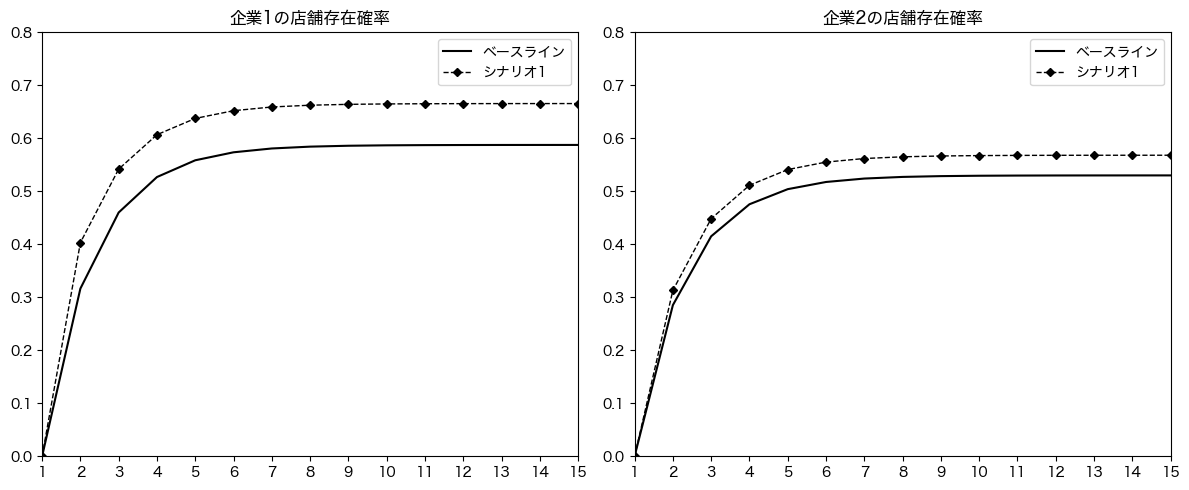

保存しました: output/ProbEntry1Original.png


In [10]:
periods = range(1, NumSimPeriods + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 企業1
axes[0].plot(periods, n1, 'k-', linewidth=1.5, label='ベースライン')
axes[0].plot(periods, n1_cf_s1, 'k--D', markersize=4, linewidth=1, label='シナリオ1')
axes[0].set_xlim(1, 15)
axes[0].set_ylim(0, 0.8)
axes[0].set_xticks(range(1, 16))
axes[0].set_title('企業1の店舗存在確率')
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].legend()

# 企業2
axes[1].plot(periods, n2, 'k-', linewidth=1.5, label='ベースライン')
axes[1].plot(periods, n2_cf_s1, 'k--D', markersize=4, linewidth=1, label='シナリオ1')
axes[1].set_xlim(1, 15)
axes[1].set_ylim(0, 0.8)
axes[1].set_xticks(range(1, 16))
axes[1].set_title('企業2の店舗存在確率')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].legend()

plt.tight_layout()
plt.savefig(output_dir / 'ProbEntry1Original.png', dpi=150, bbox_inches='tight')
plt.show()
print("保存しました: output/ProbEntry1Original.png")


### シナリオ1: 価値関数の比較

In [11]:
diff_value_1_s1 = V1cf1 - V1base
diff_value_2_s1 = V2cf1 - V2base

print("シナリオ1: 価値関数の比較")
mat_scenario1 = np.column_stack([V1base, V2base, V1cf1, diff_value_1_s1, V2cf1])

scenario1_df = pd.DataFrame(
    mat_scenario1,
    columns=['V1(ベースライン)', 'V2(ベースライン)', 'V1(シナリオ1)', 'V1差分', 'V2(シナリオ1)'],
    index=state_labels
)
print(scenario1_df.to_string())


シナリオ1: 価値関数の比較
     V1(ベースライン)  V2(ベースライン)  V1(シナリオ1)      V1差分  V2(シナリオ1)
G00    4.656720    4.441113   5.391452  0.734731   4.706357
G01    4.587240    6.178844   5.391452  0.804211   6.503374
G10    6.568685    4.379961   7.677931  1.109246   4.706357
G11    6.158792    5.776373   7.677931  1.519139   6.503374
B00    4.612305    4.401307   5.329225  0.716920   4.657847
B01    4.546091    5.629909   5.329225  0.783134   5.943157
B10    6.015729    4.342770   7.108615  1.092886   4.657847
B11    5.608719    5.229637   7.108615  1.499897   5.943157


## 反実仮想シナリオ2

企業1のベース利潤が0.5に上昇し、顧客奪取効果に企業間で異質性がある場合。
企業1の顧客奪取効果は-0.1、企業2は-0.2。

In [12]:
# シナリオ2のパラメータ
CounterfactualParameterValues2 = np.array([
    0.5,             # 企業1のベース利潤（上昇）
    -0.1,            # ライバルの店舗数が企業1の利潤に与える影響
    Parameters[3],   # 景気が良い時の企業1への追加的利潤
    Parameters[4],   # 企業1の退出のためのコスト
    Parameters[5],   # 企業1の出店のためのコスト
    Parameters[1],   # 企業2のベース利潤
    -0.2,            # ライバルの店舗数が企業2の利潤に与える影響
    Parameters[3],   # 景気が良い時の企業2への追加的利潤
    Parameters[4],   # 企業2の退出のためのコスト
    Parameters[5],   # 企業2の出店のためのコスト
])

print("シナリオ2パラメータ:", CounterfactualParameterValues2)

# 利潤行列の計算
pi1_cf2 = pi1gen(CounterfactualParameterValues2) * CCP1Adjuster
pi2_cf2 = pi2gen(CounterfactualParameterValues2) * CCP2Adjuster

# MPEを解く
CCP1cf2, CCP2cf2, V1cf2, V2cf2 = f_MPE(TransitionMat, pi1_cf2, pi2_cf2, beta)

# シナリオ2の遷移行列
fPsigma_cf2 = fP(TransitionMat, CCP1cf2[:, 1], CCP2cf2[:, 1])

# 状態分布のシミュレーション
# R code と同様にベースラインの transitionpath を使用
transitionpath_cf2 = np.zeros((NumSimPeriods, 8))
for t in range(NumSimPeriods):
    if t == 0:
        transitionpath_cf2[t] = initial_state
    else:
        transitionpath_cf2[t] = fPsigma_cf2.T @ transitionpath[t - 1]

# 店舗存在確率
n1_cf_s2 = (transitionpath_cf2 * n1_mask).sum(axis=1)
n2_cf_s2 = (transitionpath_cf2 * n2_mask).sum(axis=1)

print("\nシナリオ2の店舗存在確率:")
cf2_df = pd.DataFrame({
    '期': range(1, NumSimPeriods + 1),
    '企業1 (n1)': n1_cf_s2,
    '企業2 (n2)': n2_cf_s2
})
print(cf2_df.to_string(index=False))


シナリオ2パラメータ: [ 0.5  -0.1   0.45 -0.15 -2.1   0.2  -0.2   0.45 -0.15 -2.1 ]
MPE収束: 5 回の反復, 差分 = 6.73e-15

シナリオ2の店舗存在確率:
 期  企業1 (n1)  企業2 (n2)
 1  0.000000  0.000000
 2  0.392937  0.286598
 3  0.530733  0.418589
 4  0.595377  0.479987
 5  0.625996  0.508934
 6  0.640598  0.522691
 7  0.647593  0.529261
 8  0.650955  0.532408
 9  0.652574  0.533918
10  0.653354  0.534643
11  0.653731  0.534992
12  0.653912  0.535160
13  0.654000  0.535240
14  0.654043  0.535279
15  0.654063  0.535297


### シナリオ2: 店舗存在確率のプロット

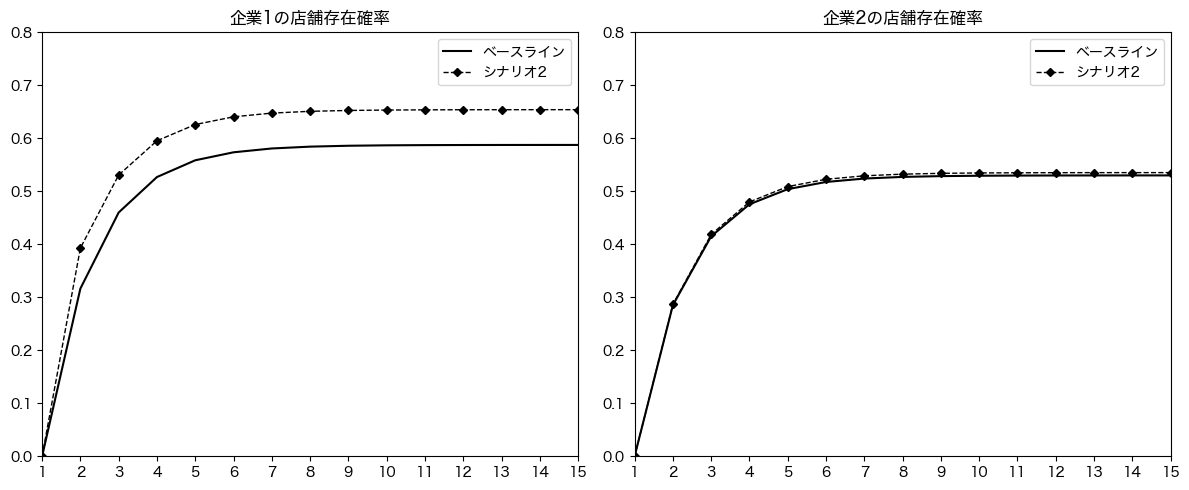

保存しました: output/ProbEntry2Original.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 企業1
axes[0].plot(periods, n1, 'k-', linewidth=1.5, label='ベースライン')
axes[0].plot(periods, n1_cf_s2, 'k--D', markersize=4, linewidth=1, label='シナリオ2')
axes[0].set_xlim(1, 15)
axes[0].set_ylim(0, 0.8)
axes[0].set_xticks(range(1, 16))
axes[0].set_title('企業1の店舗存在確率')
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].legend()

# 企業2
axes[1].plot(periods, n2, 'k-', linewidth=1.5, label='ベースライン')
axes[1].plot(periods, n2_cf_s2, 'k--D', markersize=4, linewidth=1, label='シナリオ2')
axes[1].set_xlim(1, 15)
axes[1].set_ylim(0, 0.8)
axes[1].set_xticks(range(1, 16))
axes[1].set_title('企業2の店舗存在確率')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].legend()

plt.tight_layout()
plt.savefig(output_dir / 'ProbEntry2Original.png', dpi=150, bbox_inches='tight')
plt.show()
print("保存しました: output/ProbEntry2Original.png")


### シナリオ2: 価値関数の比較

In [14]:
diff_value_1_s2 = V1cf2 - V1base
diff_value_2_s2 = V2cf2 - V2base

print("シナリオ2: 価値関数の比較")
mat_scenario2 = np.column_stack([V1base, V2base, V1cf2, diff_value_1_s2, V2cf2])

scenario2_df = pd.DataFrame(
    mat_scenario2,
    columns=['V1(ベースライン)', 'V2(ベースライン)', 'V1(シナリオ2)', 'V1差分', 'V2(シナリオ2)'],
    index=state_labels
)
print(scenario2_df.to_string())


シナリオ2: 価値関数の比較
     V1(ベースライン)  V2(ベースライン)  V1(シナリオ2)      V1差分  V2(シナリオ2)
G00    4.656720    4.441113   5.274653  0.617933   4.461638
G01    4.587240    6.178844   5.242268  0.655027   6.197212
G10    6.568685    4.379961   7.543476  0.974791   4.420688
G11    6.158792    5.776373   7.387172  1.228380   5.908007
B00    4.612305    4.401307   5.216073  0.603769   4.420732
B01    4.546091    5.629909   5.185019  0.638928   5.646942
B10    6.015729    4.342770   6.978289  0.962559   4.380926
B11    5.608719    5.229637   6.822704  1.213985   5.357419


## 表11.6: 反実仮想シミュレーション結果のまとめ

シナリオ1・2の結果をまとめてCSVに保存する。

In [15]:
# mat_all = cbind(mat_scenario1, mat_scenario2[:, 2:4])
# mat_scenario1: [V1base, V2base, V1cf1, diff1_s1, V2cf1]  (5列)
# mat_scenario2[:, 2:4]: [V1cf2, diff1_s2, V2cf2]           (3列)
mat_all = np.hstack([mat_scenario1, mat_scenario2[:, 2:5]])

# CSV保存 (R版と同じフォーマット)
mat_all_df = pd.DataFrame(
    mat_all,
    columns=['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8']
)
mat_all_df.index = range(1, 9)
mat_all_df.to_csv(output_dir / 'Tab11_6_CF_simulation.csv')
print("保存しました: output/Tab11_6_CF_simulation.csv")

# 見やすい形式で表示
print("\n表11.6: 反実仮想シミュレーション結果")
display_df = pd.DataFrame(
    mat_all,
    columns=[
        'V1(基準)', 'V2(基準)',
        'V1(S1)', 'V1差分(S1)', 'V2(S1)',
        'V1(S2)', 'V1差分(S2)', 'V2(S2)'
    ],
    index=state_labels
)
print(display_df.to_string())

# R出力との比較
try:
    r_tab = pd.read_csv(output_dir / 'Tab11_6_CF_simulation.csv', index_col=0)
    r_values = r_tab.values
    diff = np.abs(mat_all - r_values)
    print(f"\nR出力との最大差: {diff.max():.2e}")
except Exception as e:
    print(f"\nR出力との比較をスキップ: {e}")


保存しました: output/Tab11_6_CF_simulation.csv

表11.6: 反実仮想シミュレーション結果
       V1(基準)    V2(基準)    V1(S1)  V1差分(S1)    V2(S1)    V1(S2)  V1差分(S2)    V2(S2)
G00  4.656720  4.441113  5.391452  0.734731  4.706357  5.274653  0.617933  4.461638
G01  4.587240  6.178844  5.391452  0.804211  6.503374  5.242268  0.655027  6.197212
G10  6.568685  4.379961  7.677931  1.109246  4.706357  7.543476  0.974791  4.420688
G11  6.158792  5.776373  7.677931  1.519139  6.503374  7.387172  1.228380  5.908007
B00  4.612305  4.401307  5.329225  0.716920  4.657847  5.216073  0.603769  4.420732
B01  4.546091  5.629909  5.329225  0.783134  5.943157  5.185019  0.638928  5.646942
B10  6.015729  4.342770  7.108615  1.092886  4.657847  6.978289  0.962559  4.380926
B11  5.608719  5.229637  7.108615  1.499897  5.943157  6.822704  1.213985  5.357419

R出力との最大差: 2.22e-16


## 結果のまとめプロット

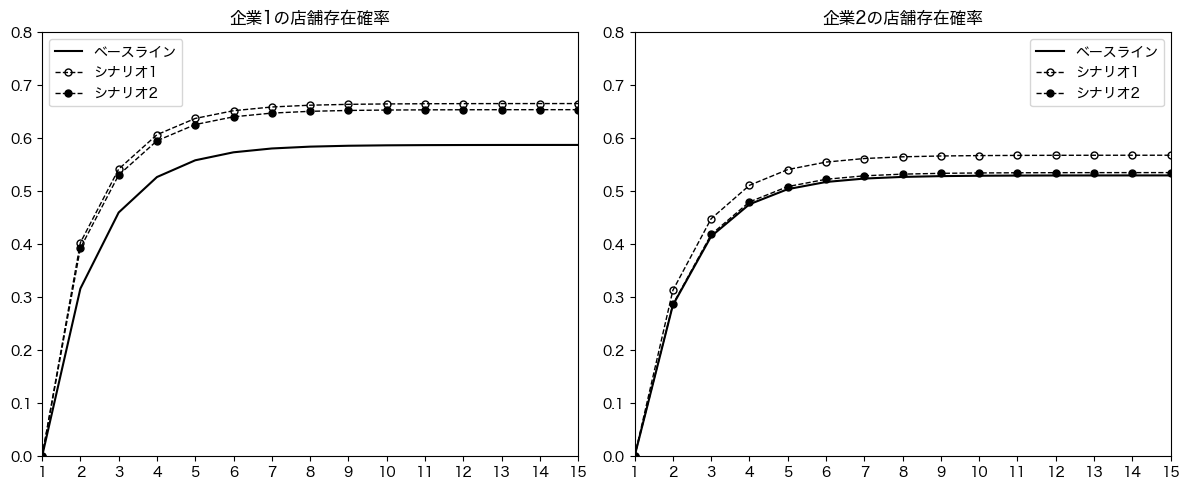

保存しました: output/ProbEntry3Plots.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 企業1
axes[0].plot(periods, n1, 'k-', linewidth=1.5, label='ベースライン')
axes[0].plot(periods, n1_cf_s1, 'k--o', markersize=5, markerfacecolor='none',
             linewidth=1, label='シナリオ1')
axes[0].plot(periods, n1_cf_s2, 'k--o', markersize=5, markerfacecolor='black',
             linewidth=1, label='シナリオ2')
axes[0].set_xlim(1, 15)
axes[0].set_ylim(0, 0.8)
axes[0].set_xticks(range(1, 16))
axes[0].set_title('企業1の店舗存在確率')
axes[0].set_xlabel('')
axes[0].set_ylabel('')
axes[0].legend()

# 企業2
axes[1].plot(periods, n2, 'k-', linewidth=1.5, label='ベースライン')
axes[1].plot(periods, n2_cf_s1, 'k--o', markersize=5, markerfacecolor='none',
             linewidth=1, label='シナリオ1')
axes[1].plot(periods, n2_cf_s2, 'k--o', markersize=5, markerfacecolor='black',
             linewidth=1, label='シナリオ2')
axes[1].set_xlim(1, 15)
axes[1].set_ylim(0, 0.8)
axes[1].set_xticks(range(1, 16))
axes[1].set_title('企業2の店舗存在確率')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].legend()

plt.tight_layout()
plt.savefig(output_dir / 'ProbEntry3Plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("保存しました: output/ProbEntry3Plots.png")


## まとめ

In [17]:
print("=" * 60)
print("第11章: 動学ゲーム 反実仮想シミュレーション まとめ")
print("=" * 60)
print(f"状態空間: 8 状態 (景気{{G,B}} x n1{{0,1}} x n2{{0,1}})")
print(f"各企業の行動: 3種類 (退出=-1, 現状維持=0, 参入=1)")
print(f"割引因子 beta = {beta}")
print(f"遷移行列: P(G|G)={TransitionMat[0,0]}, P(B|B)={TransitionMat[1,1]}")
print()
print("シナリオ1: 企業1のベース利潤=0.5, 顧客奪取効果=0 (両企業)")
print(f"  ベースラインパラメータ: {BaselineParameterValues}")
print(f"  シナリオ1パラメータ:    {CounterfactualParameterValues1}")
print()
print("シナリオ2: 企業1のベース利潤=0.5, 顧客奪取効果: 企業1=-0.1, 企業2=-0.2")
print(f"  シナリオ2パラメータ:    {CounterfactualParameterValues2}")
print()
print("出力ファイル:")
print("  - ProbEntry1Original.png (シナリオ1 店舗存在確率)")
print("  - ProbEntry2Original.png (シナリオ2 店舗存在確率)")
print("  - ProbEntry3Plots.png    (まとめプロット)")
print("  - Tab11_6_CF_simulation.csv (表11.6)")
print()
print("完了")


第11章: 動学ゲーム 反実仮想シミュレーション まとめ
状態空間: 8 状態 (景気{G,B} x n1{0,1} x n2{0,1})
各企業の行動: 3種類 (退出=-1, 現状維持=0, 参入=1)
割引因子 beta = 0.8
遷移行列: P(G|G)=0.7, P(B|B)=0.6

シナリオ1: 企業1のベース利潤=0.5, 顧客奪取効果=0 (両企業)
  ベースラインパラメータ: [ 0.3  -0.27  0.45 -0.15 -2.1   0.2  -0.27  0.45 -0.15 -2.1 ]
  シナリオ1パラメータ:    [ 0.5   0.    0.45 -0.15 -2.1   0.2   0.    0.45 -0.15 -2.1 ]

シナリオ2: 企業1のベース利潤=0.5, 顧客奪取効果: 企業1=-0.1, 企業2=-0.2
  シナリオ2パラメータ:    [ 0.5  -0.1   0.45 -0.15 -2.1   0.2  -0.2   0.45 -0.15 -2.1 ]

出力ファイル:
  - ProbEntry1Original.png (シナリオ1 店舗存在確率)
  - ProbEntry2Original.png (シナリオ2 店舗存在確率)
  - ProbEntry3Plots.png    (まとめプロット)
  - Tab11_6_CF_simulation.csv (表11.6)

完了
